<a href="https://colab.research.google.com/github/marcosalamina86/DoE/blob/main/DoE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # Design of Experiment (DoE) Program

This notebook will guide you through creating a modular program for Design of Experiments (DoE). The goal is to help scientists design efficient experiments, track variables, analyze interactions, and identify optimal conditions while minimizing experimental runs.

Module 1 - setup and introduction

Module 2 - Interactive Variables definition


Module 3 - Advanced Experimental DesignGeneration


Module 4 - Experimental Data Management: prepare for data collection


Module 5 - Data Analysis and Model Fitting


Module 6 - Comphensive Visualization


Module 7 - Optimal Conditions Prediction




## Module 1: Setup and Introduction to DoE

This module focuses on setting up our Python environment by installing necessary libraries and providing a brief introduction to Design of Experiments. DoE is a systematic method to determine the relationship between factors affecting a process and the output of that process. By using DoE, you can understand variable interactions, optimize processes, and improve reproducibility with fewer experiments.

In [ ]:
# Install necessary libraries
!pip install pandas matplotlib seaborn

In [ ]:
# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Removed: from pyDOE2 import * due to Python 3.12 incompatibility

print("Libraries installed and imported successfully (excluding pyDOE2)!")

Libraries installed and imported successfully (excluding pyDOE2)!


## Module 2: Defining Experimental Variables (Factors and Responses)

This module will guide you through identifying and defining the independent variables (factors, often denoted as X) that you will manipulate in your experiment, and the dependent variables (responses, often denoted as Y) that you will measure. Clearly defining these variables is crucial for selecting the right experimental design and ensuring meaningful analysis.

### 2.1 Factors (Independent Variables - X)

Factors are the input variables or conditions that you can control and change during your experiment. For each factor, you need to define its name, its type (e.g., categorical, continuous), and its range or levels. Understanding the user's capabilities and constraints (e.g., number of replicates) will be important when setting these levels.

In [ ]:
import pandas as pd
import numpy as np

factors_data = {'Name': [], 'Type': [], 'Units': [], 'Levels': []}

try:
    num_factors = int(input("Enter the number of factors: "))

    for i in range(num_factors):
        print(f"\n--- Factor {i+1} ---")
        name = input("Name: ")
        f_type = input("Type (con/cat): ").lower().strip()
        units = input("Units: ")

        if f_type.startswith('con'):
            low = float(input(f"Min for {name}: "))
            high = float(input(f"Max for {name}: "))
            pts = int(input(f"How many points to check for {name}? (e.g., 2 for min/max, 3 for min/mid/max): "))
            levels = np.linspace(low, high, pts).tolist()
            factor_type = 'Continuous'
        else:
            num_levels = int(input(f"Number of levels for {name}: "))
            levels = [input(f"Level {j+1}: ") for j in range(num_levels)]
            factor_type = 'Categorical'

        factors_data['Name'].append(name)
        factors_data['Type'].append(factor_type)
        factors_data['Units'].append(units)
        factors_data['Levels'].append(levels)

    df_factors = pd.DataFrame(factors_data)
    display(df_factors)
except ValueError as e:
    print(f"Input Error: {e}")

Enter the number of factors: 3

--- Factor 1 ---
Name: f1
Type (con/cat): con
Units: x
Min for f1: 10
Max for f1: 200
How many points to check for f1? (e.g., 2 for min/max, 3 for min/mid/max): 5

--- Factor 2 ---
Name: F2
Type (con/cat): cat
Units: y
Number of levels for F2: 5
Level 1: A
Level 2: B
Level 3: C
Level 4: D
Level 5: E

--- Factor 3 ---
Name: F3
Type (con/cat): con
Units: z
Min for F3: 90
Max for F3: 190
How many points to check for F3? (e.g., 2 for min/max, 3 for min/mid/max): 3


,Name,Type,Units,Levels
0,f1,Continuous,x,"[10.0, 57.5, 105.0, 152.5, 200.0]"
1,F2,Categorical,y,"[A, B, C, D, E]"
2,F3,Continuous,z,"[90.0, 140.0, 190.0]"


### 2.2 Responses (Dependent Variables - Y)

Responses are the measurable outcomes of your experiment. For each response, you need to define its name, its type (e.g., 'Continuous', 'Categorical'), and its units. Understanding how to measure these responses accurately is key to a successful DoE.

In [ ]:
# Define Responses Interactively

responses_data = {'Name': [], 'Type': [], 'Units': []}

num_responses = int(input("Enter the number of responses (dependent variables) you want to define: "))

for i in range(num_responses):
    print(f"\n--- Response {i+1} ---")
    name = input("Enter response name (e.g., Yield): ")
    response_type = input("Enter response type (Continuous/Categorical): ").capitalize()
    units = input("Enter units for this response (e.g., %, minutes): ")

    responses_data['Name'].append(name)
    responses_data['Type'].append(response_type)
    responses_data['Units'].append(units)

df_responses = pd.DataFrame(responses_data)
print("\nDefined Responses:")
display(df_responses)

Enter the number of responses (dependent variables) you want to define: 1

--- Response 1 ---
Enter response name (e.g., Yield): resp
Enter response type (Continuous/Categorical): Continuous
Enter units for this response (e.g., %, minutes): w

Defined Responses:


,Name,Type,Units
0,resp,Continuous,w


## Module 3: Experimental Design Generation

With your factors and responses defined, this module will focus on generating an experimental design. The design specifies the combination of factor levels for each experimental run. The choice of design depends on the number of factors, their types, and the experimental objectives (e.g., screening, optimization).

Since `pyDOE2` had compatibility issues, we will implement a basic Full Factorial Design using `pandas` and `numpy` to illustrate the concept. For more complex designs (like Fractional Factorial, Central Composite, or Box-Behnken), specialized libraries or manual construction would be required.

### 3.1 Generating a Full Factorial Design

A Full Factorial Design includes all possible combinations of the levels of all factors. While it can be resource-intensive for many factors, it allows for the estimation of all main effects and interactions.

In [ ]:
# Generate Full Factorial Design

# Prepare factor levels for design generation
factor_levels_for_design = []
for index, row in df_factors.iterrows():
    if row['Type'] == 'Continuous':
        # For continuous factors, we typically use the min and max as levels in a full factorial
        factor_levels_for_design.append(row['Levels'])
    elif row['Type'] == 'Categorical':
        factor_levels_for_design.append(row['Levels'])

# Create all combinations using itertools.product
import itertools
experiment_runs = list(itertools.product(*factor_levels_for_design))

# Create a DataFrame for the experimental design
df_design = pd.DataFrame(experiment_runs, columns=df_factors['Name'])

print("\nGenerated Full Factorial Design:")
display(df_design)
print(f"Total number of experimental runs: {len(df_design)}")


Generated Full Factorial Design:


Name,f1,F2,F3
0,10.0,A,90.0
1,10.0,A,140.0
2,10.0,A,190.0
3,10.0,B,90.0
4,10.0,B,140.0
...,...,...,...
70,200.0,D,140.0
71,200.0,D,190.0
72,200.0,E,90.0
73,200.0,E,140.0


Total number of experimental runs: 75


### 3.2 Advanced Design: Fractional and Custom Designs

When resource constraints exist, we can use **Fractional Factorial Designs** to reduce the number of runs while still capturing main effects. We can also define a **Custom Design** by specifying the maximum number of runs allowed.

#### Understanding Resolution and Power
- **Resolution**: This refers to the degree of "aliasing" or confounding in your design.
    - *High Resolution (e.g., Res V+):* Main effects and 2-way interactions are clear.
    - *Low Resolution (e.g., Res III):* Main effects might be confounded with 2-way interactions, meaning you can't tell which one caused the change in Y.
- **Power**: The probability that your experiment will detect an effect of a specific size. As you reduce the number of runs (Fractional/Custom), your statistical **power** generally decreases, making it harder to distinguish true signals from background noise.

In [ ]:
import itertools
import pandas as pd
import numpy as np

def generate_complex_design():
    if df_factors.empty:
        print("Define factors first.")
        return

    print("\n1. Full Factorial\n2. Fractional (Half)\n3. Custom (Specify Max Total Runs)")
    choice = input("Choice (1/2/3): ")

    factor_levels = [row['Levels'] for _, row in df_factors.iterrows()]
    full_list = list(itertools.product(*factor_levels))
    df_base = pd.DataFrame(full_list, columns=df_factors['Name'])

    print("\nReplication Strategy:")
    print("1. Duplicate entire design")
    print("2. Replicate a subset of runs")
    rep_choice = input("Choice (1/2): ")

    if choice == '3':
        max_total_allowed = int(input("Enter the maximum total number of runs allowed (including replicates): "))

        if rep_choice == '1':
            reps = int(input("How many times to run the whole design (e.g., 2 for double)? "))
            n_unique = max_total_allowed // reps
            if n_unique < 1:
                print(f"Error: With {reps} replicates, you need a total budget of at least {reps} runs.")
                return None
            df_selected = df_base.sample(n=min(n_unique, len(df_base)), random_state=42)
            df_final = pd.concat([df_selected] * reps).reset_index(drop=True)
        else:
            sub_n = int(input("How many runs should be replicated? "))
            if sub_n >= max_total_allowed:
                print(f"Error: Replicates ({sub_n}) must be less than the total runs ({max_total_allowed}).")
                return None
            n_unique = max_total_allowed - sub_n
            df_selected = df_base.sample(n=min(n_unique, len(df_base)), random_state=42)
            df_sub = df_selected.sample(n=min(sub_n, len(df_selected)), random_state=42)
            df_final = pd.concat([df_selected, df_sub]).reset_index(drop=True)
    else:
        if choice == '2':
            df_selected = df_base.iloc[::2, :]
        else:
            df_selected = df_base

        if rep_choice == '1':
            reps = int(input("How many times to run the whole design? "))
            df_final = pd.concat([df_selected] * reps).reset_index(drop=True)
        else:
            sub_n = int(input("How many runs should be replicated? "))
            df_sub = df_selected.sample(n=min(sub_n, len(df_selected)), random_state=42)
            df_final = pd.concat([df_selected, df_sub]).reset_index(drop=True)

    print(f"\n--- Design Summary ---")
    print(f"Total Runs (Final Count): {len(df_final)}")
    print(f"Unique Combinations: {len(df_selected)}")
    print(f"Factors: {len(df_factors)}")
    return df_final

df_design = generate_complex_design()


1. Full Factorial
2. Fractional (Half)
3. Custom (Specify Max Total Runs)
Choice (1/2/3): 3

Replication Strategy:
1. Duplicate entire design
2. Replicate a subset of runs
Choice (1/2): 2
Enter the maximum total number of runs allowed (including replicates): 30
How many runs should be replicated? 3

--- Design Summary ---
Total Runs (Final Count): 30
Unique Combinations: 27
Factors: 3


### 3.3 Power Comparison: Full vs. Fractional vs. Custom

Statistical **Power** is the probability of correctly rejecting the null hypothesis when a true effect exists. In this module, we simulate a standard effect size and calculate the power for each design generated so far. This helps you visualize the trade-off between the number of runs and the reliability of your results.

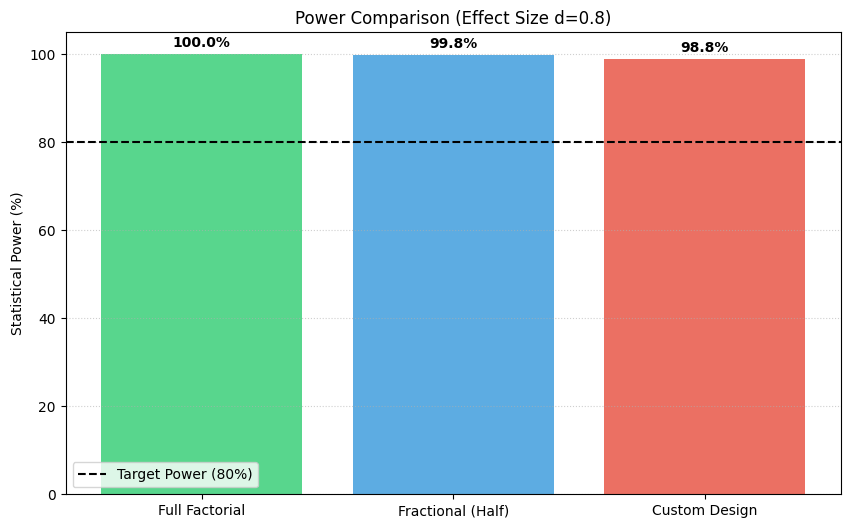

--- Run Count Summary ---
Full Factorial: 75 runs
Fractional (Half): 38 runs
Custom Design: 30 runs


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
from statsmodels.stats.power import TTestPower

def analyze_power_comparison():
    # 1. Prepare the candidate designs
    factor_levels = [row['Levels'] for _, row in df_factors.iterrows()]
    full_list = list(itertools.product(*factor_levels))
    df_full = pd.DataFrame(full_list, columns=df_factors['Name'])

    # Fractional (Half)
    df_fractional = df_full.iloc[::2, :]

    # Custom (Current df_design)
    df_custom = df_design

    designs = {
        'Full Factorial': len(df_full),
        'Fractional (Half)': len(df_fractional),
        'Custom Design': len(df_custom)
    }

    # 2. Power Calculation Parameters
    # effect_size: Cohen's d (difference in means / std_dev)
    # We'll assume a 'Medium' effect size of 0.8 for comparison
    effect_size = 0.8
    alpha = 0.05
    analysis = TTestPower()

    powers = {}
    for name, n_runs in designs.items():
        # Power for a t-test given the sample size (n_runs)
        p = analysis.power(effect_size=effect_size, nobs=n_runs, alpha=alpha)
        powers[name] = p

    # 3. Visualization
    plt.figure(figsize=(10, 6))
    colors = ['#2ecc71', '#3498db', '#e74c3c']
    bars = plt.bar(powers.keys(), [p * 100 for p in powers.values()], color=colors, alpha=0.8)

    plt.axhline(80, color='black', linestyle='--', label='Target Power (80%)')
    plt.ylim(0, 105)
    plt.ylabel('Statistical Power (%)')
    plt.title(f'Power Comparison (Effect Size d={effect_size})')

    # Add labels on top of bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom', fontweight='bold')

    plt.legend()
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    plt.show()

    print("--- Run Count Summary ---")
    for name, n in designs.items():
        print(f"{name}: {n} runs")

analyze_power_comparison()

### 3.4 Exhaustive Design Comparison: Trade-offs in DoE

Choosing the right design involves balancing **Resolution**, **Runs**, and **Power**:

1.  **Full Factorial**: Tests all combinations. High Power, No Aliasing, but very expensive.
2.  **Fractional Factorial**: Tests a fraction (1/2, 1/4, etc.). Good balance of power and efficiency.
3.  **Plackett-Burman / Screening**: Extremely efficient for many factors but high aliasing. Used early in research.
4.  **Custom / D-Optimal**: Mathematically optimized to fit a specific run budget. Power varies based on the budget provided.

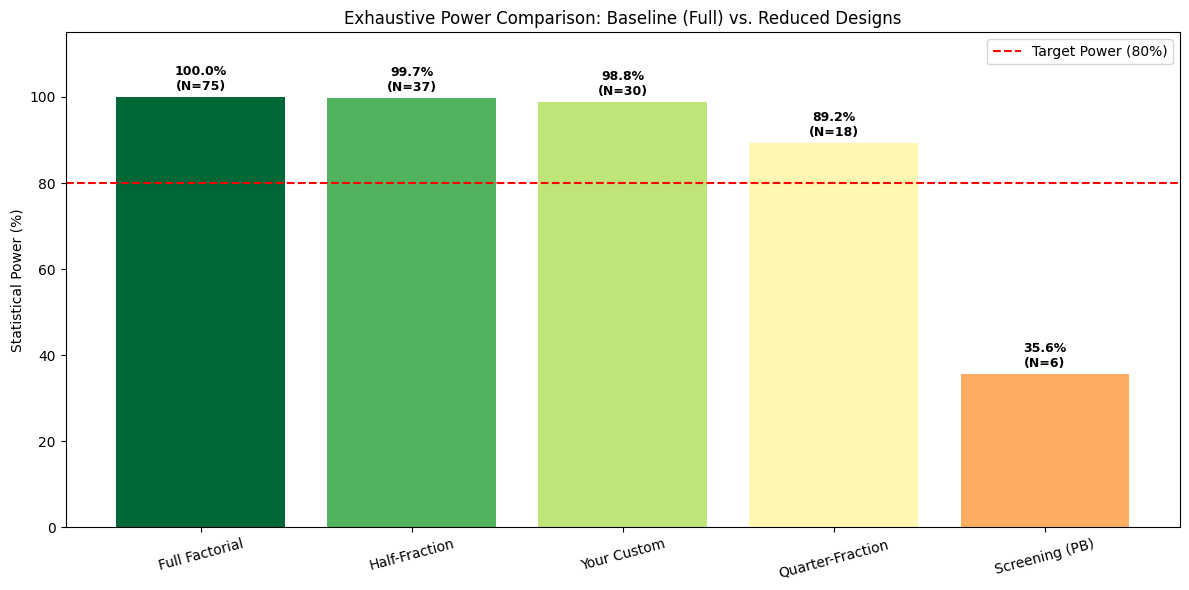

--- Detailed Run Count Summary ---
Full Factorial: 75 runs
Half-Fraction: 37 runs
Quarter-Fraction: 18 runs
Screening (PB): 6 runs
Your Custom: 30 runs


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.power import TTestPower
import itertools

def exhaustive_power_analysis():
    # Calculate possible run counts for different design types for the current factors
    # Full Factorial: All combinations
    n_full = len(list(itertools.product(*[row['Levels'] for _, row in df_factors.iterrows()])))

    # Fractional designs
    n_half = n_full // 2
    n_quarter = n_full // 4

    # Screening designs typically scale with number of factors
    n_screening = len(df_factors) * 2

    # The specific custom design generated in the previous step
    n_custom = len(df_design)

    design_map = {
        'Full Factorial': n_full,
        'Half-Fraction': n_half,
        'Quarter-Fraction': n_quarter,
        'Screening (PB)': n_screening,
        'Your Custom': n_custom
    }

    analysis = TTestPower()
    effect_size = 0.8 # Medium-Large effect
    alpha = 0.05

    # Calculate power for each run count
    results = {name: analysis.power(effect_size=effect_size, nobs=n, alpha=alpha) for name, n in design_map.items()}

    # Plotting
    plt.figure(figsize=(12, 6))
    # Sort by power descending
    sorted_results = dict(sorted(results.items(), key=lambda item: item[1], reverse=True))

    colors = plt.cm.RdYlGn(np.linspace(0.3, 1, len(sorted_results)))
    bars = plt.bar(sorted_results.keys(), [p*100 for p in sorted_results.values()], color=colors[::-1])

    plt.axhline(80, color='red', linestyle='--', label='Target Power (80%)')
    plt.ylabel('Statistical Power (%)')
    plt.title('Exhaustive Power Comparison: Baseline (Full) vs. Reduced Designs')
    plt.xticks(rotation=15)

    # Add numeric labels and run counts to bars
    for bar, name in zip(bars, sorted_results.keys()):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.1f}%\n(N={design_map[name]})',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.legend()
    plt.ylim(0, 115) # Leave space for labels
    plt.tight_layout()
    plt.show()

    print("--- Detailed Run Count Summary ---")
    for k, v in design_map.items():
        print(f"{k}: {v} runs")

exhaustive_power_analysis()

**Reasoning**:
First, I will augment the `df_design` DataFrame by adding new columns for each response variable from `df_responses`, initialized with `np.nan`. This prepares the DataFrame for data collection as per the instructions.



In [ ]:
# Augment the newly generated df_design with response columns
for response_name in df_responses['Name']:
    df_design[response_name] = np.nan

print("Augmented Experimental Design (with response columns):")
display(df_design.head())

Augmented Experimental Design (with response columns):


Name,f1,F2,F3,resp
0,10.0,B,140.0,NaN
1,200.0,B,90.0,NaN
2,10.0,D,140.0,NaN
3,10.0,A,90.0,NaN
4,105.0,B,190.0,NaN


**Reasoning**:
Now that the `df_design` DataFrame has been augmented with response columns, I will export it to an Excel file to serve as a template for experimental data collection.



In [ ]:
# Export the finalized design to Excel
output_filename = 'experimental_design_template.xlsx'
df_design.to_excel(output_filename, index=False)

print(f"Experimental design template exported successfully to '{output_filename}'.")
print("You can now download this file from the Colab file explorer on the left.")

Experimental design template exported successfully to 'experimental_design_template.xlsx'.
You can now download this file from the Colab file explorer on the left.


## Module 4: Data Re-import and Simulation

In a real-world scenario, you would now perform the experiments listed in the Excel file and record the results. For this program, we will provide a way to re-import that data. If you don't have results yet, the code below can simulate them so we can test the analysis modules.

In [ ]:
import pandas as pd
import numpy as np

def interactive_data_entry(filename='experimental_design_template.xlsx'):
    try:
        df = pd.read_excel(filename)
        print("--- Interactive Data Entry ---")
        print("1. Manual Entry (Input results for each run)")
        print("2. Simulation (Generate synthetic data)")
        print("3. Load Existing (File already contains results)")

        choice = input("Select an option (1/2/3): ")

        if choice == '1':
            for response in df_responses['Name']:
                print(f"\nEntering results for: {response}")
                for idx, row in df.iterrows():
                    # Show factors for context
                    factor_desc = ", ".join([f"{col}: {row[col]}" for col in df_factors['Name']])
                    val = input(f"Run {idx+1} [{factor_desc}] -> {response}: ")
                    df.at[idx, response] = float(val)

        elif choice == '2':
            print("\nSimulating data based on factor trends...")
            for response in df_responses['Name']:
                noise = np.random.normal(0, 2, size=len(df))
                # Mock linear relationship
                v1_eff = df['v1'] * 5 if 'v1' in df.columns else 0
                df[response] = 50 + v1_eff + noise

        print("\nUpdated Dataset:")
        display(df.head())
        return df
    except Exception as e:
        print(f"Error: {e}")
        return None

# Run the interactive loader
df_analysis = interactive_data_entry()

--- Interactive Data Entry ---
1. Manual Entry (Input results for each run)
2. Simulation (Generate synthetic data)
3. Load Existing (File already contains results)
Select an option (1/2/3): 2

Simulating data based on factor trends...

Updated Dataset:


,f1,F2,F3,resp
0,10.0,B,140,51.389062
1,200.0,B,90,46.795920
2,10.0,D,140,49.095496
3,10.0,A,90,49.709720
4,105.0,B,190,51.649321


## Module 5: Statistical Analysis

Now that we have experimental results (either simulated or entered), we perform regression analysis to understand the relationship between our factors and the responses. We will use the `statsmodels` library to perform an Ordinary Least Squares (OLS) regression.

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

def perform_regression(df, response_col, factors):
    # Construct the formula: Response ~ Factor1 + Factor2 + ...
    # Using C(factor) for categorical variables
    formula_parts = []
    for f in factors:
        f_type = df_factors.loc[df_factors['Name'] == f, 'Type'].values[0]
        if f_type == 'Categorical':
            formula_parts.append(f"C({f})")
        else:
            formula_parts.append(f)

    # Quote the response_col using Q() to handle special characters like apostrophes
    formula = f"Q('{response_col}') ~ {' + '.join(formula_parts)}"
    print(f"Fitting Model: {formula}")

    model = smf.ols(formula, data=df).fit()
    return model

# Run analysis for the defined response
response_to_analyze = df_responses['Name'].iloc[0]
factors_list = df_factors['Name'].tolist()

model_fit = perform_regression(df_analysis, response_to_analyze, factors_list)
print(model_fit.summary())

Fitting Model: Q('resp') ~ f1 + C(F2) + F3
                            OLS Regression Results                            
Dep. Variable:              Q('resp')   R-squared:                       0.454
Model:                            OLS   Adj. R-squared:                  0.312
Method:                 Least Squares   F-statistic:                     3.188
Date:                Mon, 04 May 2026   Prob (F-statistic):             0.0200
Time:                        18:32:43   Log-Likelihood:                -55.331
No. Observations:                  30   AIC:                             124.7
Df Residuals:                      23   BIC:                             134.5
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept

## Module 6: Visualization

Visualization is key to communicating DoE results. A **Pareto Chart** displays the absolute value of the t-statistics for each effect, allowing us to see which factors are statistically significant at a glance.

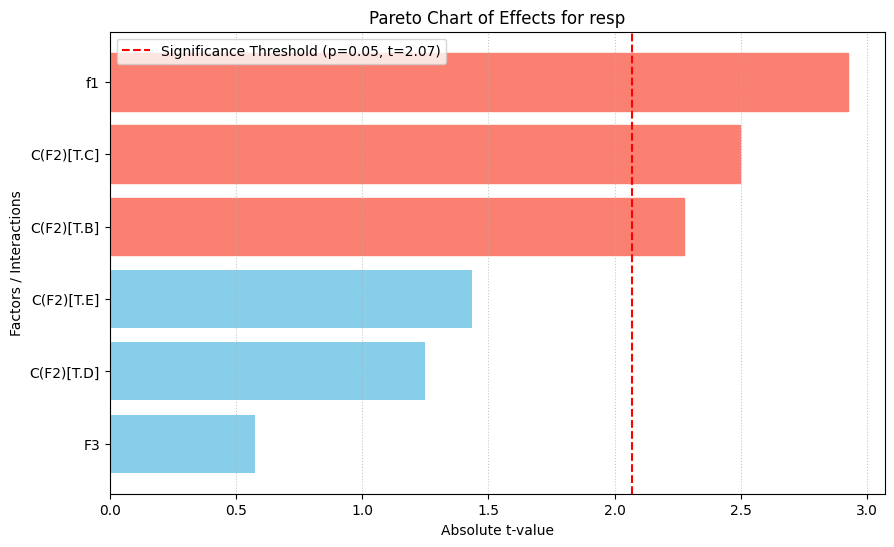

In [ ]:
import matplotlib.pyplot as plt
import scipy.stats as stats

def plot_pareto(model, response_name):
    # Get absolute t-values, excluding the Intercept
    t_values = np.abs(model.tvalues.drop('Intercept'))
    t_values = t_values.sort_values(ascending=True)

    # Calculate the t-critical value for significance (alpha=0.05)
    df_resid = model.df_resid
    t_crit = stats.t.ppf(1 - 0.025, df_resid)

    # Plotting
    plt.figure(figsize=(10, 6))
    bars = plt.barh(t_values.index, t_values.values, color='skyblue')

    # Add a vertical line for the significance threshold
    plt.axvline(x=t_crit, color='red', linestyle='--', label=f'Significance Threshold (p=0.05, t={t_crit:.2f})')

    plt.title(f'Pareto Chart of Effects for {response_name}')
    plt.xlabel('Absolute t-value')
    plt.ylabel('Factors / Interactions')
    plt.legend()
    plt.grid(axis='x', linestyle=':', alpha=0.7)

    # Highlight bars that cross the threshold
    for i, bar in enumerate(bars):
        if t_values.values[i] > t_crit:
            bar.set_color('salmon')

    plt.show()

plot_pareto(model_fit, response_to_analyze)

## Module 7: Advanced Modeling and Comparison

In this section, we move beyond linear regression to explore non-linear models and dimensionality reduction. We will compare OLS, Decision Trees, and Random Forests to identify the best predictive model for our experimental data.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


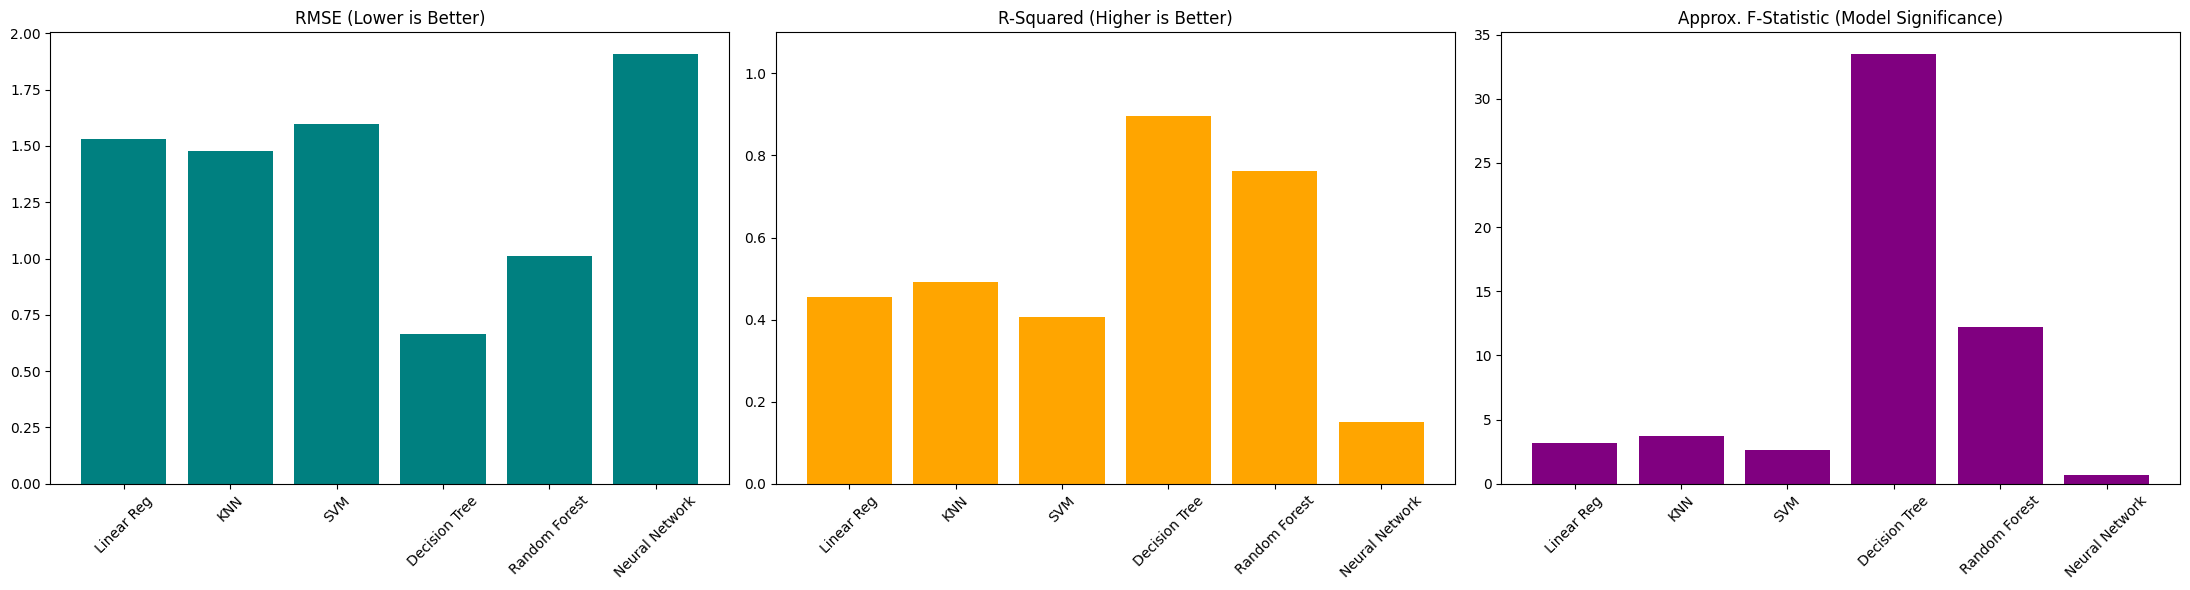

**The top performer model is: Decision Tree**

,Model,RMSE,R2,F-Stat
3,Decision Tree,0.663574,0.897331,33.503386
4,Random Forest,1.011506,0.761440,12.235273
1,KNN,1.477547,0.490970,3.697322
0,Linear Reg,1.530246,0.454011,3.187568
2,SVM,1.596437,0.405755,2.617434
5,Neural Network,1.909062,0.150230,0.677691


In [ ]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.cluster import KMeans
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import Markdown, display
import statsmodels.api as sm

def comprehensive_model_comparison(df, response_col, factors):
    # 1. Data Preparation
    X = pd.get_dummies(df[factors], drop_first=True)
    y = df[response_col]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled_sm = sm.add_constant(X_scaled) # For F-stat calculation

    results_metrics = []

    # 2. Regression Models Setup
    models = {
        'Linear Reg': LinearRegression(),
        'KNN': KNeighborsRegressor(n_neighbors=3),
        'SVM': SVR(kernel='rbf'),
        'Decision Tree': DecisionTreeRegressor(random_state=42),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
        'Neural Network': MLPRegressor(hidden_layer_sizes=(10, 10), max_iter=2000, random_state=42)
    }

    for name, model in models.items():
        model.fit(X_scaled, y)
        preds = model.predict(X_scaled)
        rmse = np.sqrt(mean_squared_error(y, preds))
        r2 = r2_score(y, preds)

        # Approximate F-statistic for the models
        n = len(y)
        p = X_scaled.shape[1]
        f_stat = (r2 / p) / ((1 - r2) / (n - p - 1)) if r2 < 1 else 100

        results_metrics.append({'Model': name, 'RMSE': rmse, 'R2': r2, 'F-Stat': f_stat})

    df_results = pd.DataFrame(results_metrics)

    # --- Visualizations ---
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))

    # Plot 1: RMSE
    axes[0].bar(df_results['Model'], df_results['RMSE'], color='teal')
    axes[0].set_title('RMSE (Lower is Better)')
    axes[0].tick_params(axis='x', rotation=45)

    # Plot 2: R-Squared
    axes[1].bar(df_results['Model'], df_results['R2'], color='orange')
    axes[1].set_title('R-Squared (Higher is Better)')
    axes[1].set_ylim(0, 1.1)
    axes[1].tick_params(axis='x', rotation=45)

    # Plot 3: F-Statistic
    axes[2].bar(df_results['Model'], df_results['F-Stat'], color='purple')
    axes[2].set_title('Approx. F-Statistic (Model Significance)')
    axes[2].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    # Identify and print the best performer
    best_model_name = df_results.loc[df_results['RMSE'].idxmin(), 'Model']
    display(Markdown(f"**The top performer model is: {best_model_name}**"))
    display(df_results.sort_values(by='RMSE'))

comprehensive_model_comparison(df_analysis, response_to_analyze, factors_list)

## Module 8: Optimization & Custom Prediction

In this final module, we identify the best performing combination from your actual data and provide a tool to predict outcomes for any custom combination of factor levels using our best-performing model.

# 🌟 OPTIMAL EXPERIMENTAL CONDITIONS

# resp: <span style='color:green'>52.80 w</span>

### **Best Settings Found:** f1: **57.5** | F2: **C** | F3: **140**

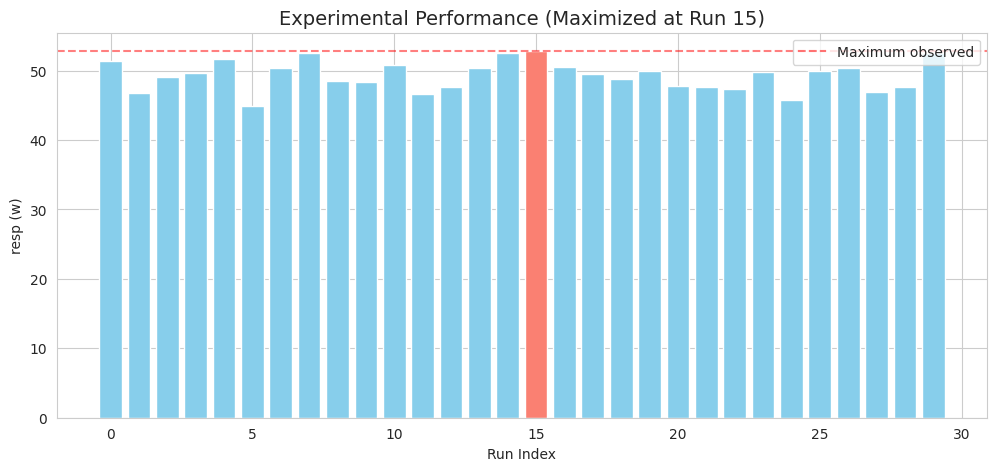

In [ ]:
from IPython.display import Markdown, display
import seaborn as sns
import matplotlib.pyplot as plt

# Find the run with the maximum response
best_idx = df_analysis[response_to_analyze].idxmax()
best_run = df_analysis.loc[best_idx]

# Display in large characters
display(Markdown(f"# 🌟 OPTIMAL EXPERIMENTAL CONDITIONS"))
display(Markdown(f"# {response_to_analyze}: <span style='color:green'>{best_run[response_to_analyze]:.2f} {df_responses.iloc[0]['Units']}</span>"))

settings_text = " | ".join([f"{col}: **{best_run[col]}**" for col in factors_list])
display(Markdown(f"### **Best Settings Found:** {settings_text}"))

# Visualization: Performance across all runs
plt.figure(figsize=(12, 5))
sns.set_style('whitegrid')
colors = ['salmon' if x == best_idx else 'skyblue' for x in df_analysis.index]
plt.bar(df_analysis.index, df_analysis[response_to_analyze], color=colors)
plt.axhline(best_run[response_to_analyze], color='red', linestyle='--', alpha=0.5, label='Maximum observed')
plt.title(f'Experimental Performance (Maximized at Run {best_idx})', fontsize=14)
plt.xlabel('Run Index')
plt.ylabel(f'{response_to_analyze} ({df_responses.iloc[0]["Units"]})')
plt.legend()
plt.show()

## Find and display top 3 optimal conditions

In [ ]:
# Find and display top 3 optimal conditions
top_3_runs = df_analysis.nlargest(3, response_to_analyze)

display(Markdown("# ⌛ Top 3 Optimal Conditions"))

for i, (idx, run) in enumerate(top_3_runs.iterrows()):
    settings = " | ".join([f"{col}: **{run[col]}**" for col in factors_list])
    display(Markdown(f"### **Rank {i+1}:** {response_to_analyze} = **{run[response_to_analyze]:.2f} {df_responses.iloc[0]['Units']}**"))
    display(Markdown(f"*Settings:* {settings}"))
    display(Markdown("---"))

# ⌛ Top 3 Optimal Conditions

### **Rank 1:** resp = **52.80 w**

*Settings:* f1: **57.5** | F2: **C** | F3: **140**

---

### **Rank 2:** resp = **52.55 w**

*Settings:* f1: **10.0** | F2: **D** | F3: **90**

---

### **Rank 3:** resp = **52.50 w**

*Settings:* f1: **10.0** | F2: **E** | F3: **90**

---

## Predict manual data

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# Train the top-performing model (Random Forest) on the full available dataset
X_final = pd.get_dummies(df_analysis[factors_list], drop_first=True)
y_final = df_analysis[response_to_analyze]
best_model = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_final, y_final)

def user_prediction_tool():
    print("\n--- Interactive Predictor: Enter factor levels ---")
    user_input = {}

    for _, row in df_factors.iterrows():
        val = input(f"Value for {row['Name']} (Available: {row['Levels']}): ")
        # Convert based on type
        if row['Type'] == 'Continuous':
            user_input[row['Name']] = [float(val)]
        else:
            user_input[row['Name']] = [val]

    # Prepare input for model (handling dummies)
    df_user = pd.DataFrame(user_input)
    df_user_encoded = pd.get_dummies(df_user).reindex(columns=X_final.columns, fill_value=0)

    pred = best_model.predict(df_user_encoded)[0]
    display(Markdown(f"# 🔮 Predicted {response_to_analyze}: **{pred:.2f} {df_responses.iloc[0]['Units']}**"))

# Execute tool
user_prediction_tool()


--- Interactive Predictor: Enter factor levels ---
Value for f1 (Available: [10.0, 57.5, 105.0, 152.5, 200.0]): 10
Value for F2 (Available: ['A', 'B', 'C', 'D', 'E']): C
Value for F3 (Available: [90.0, 140.0, 190.0]): 90


# 🔮 Predicted resp: **51.03 w**